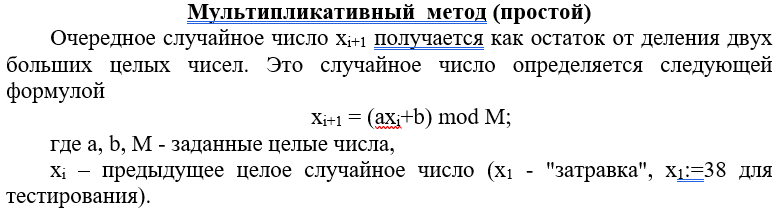
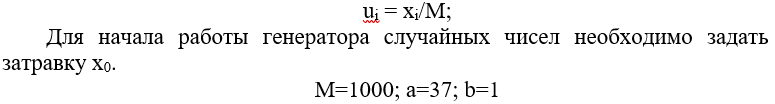

alpha = 0.05
x min x max


In [ ]:
import math
import numpy as np

def MulRandGenerate(x0,a,b,N,M):
    arr = [x0]
    
    for _ in range(1,N):
       arr.append((a * arr[-1] + b) % M)
    
    transArr = np.array([x / M for x in arr])
    
    return transArr


M = 1000
a = 37
b = 1
N = 100
x0 = 38

randArr = MulRandGenerate(x0,a,b,N,M) 

print(randArr[:10])
x_min = randArr.min()


[0.038 0.407 0.06  0.221 0.178 0.587 0.72  0.641 0.718 0.567]


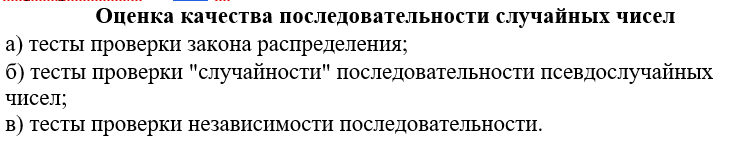

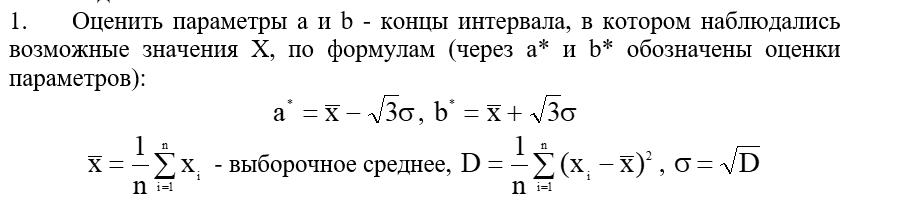

In [25]:
arrMax, arrMin = randArr.max(), randArr.min()

s = int(np.ceil(1 + 3.3221 * np.log10(N)))
h = (arrMax - arrMin) / s

print(F"Количество интервалов: {s}")
print(F"Шаг h: {h}")
print(F"Диапозон: [{arrMin},{arrMax}]")

edges = np.linspace(arrMin, arrMax, s + 1)

print(F"Границы интервалов: {edges}")

x_mean = np.mean(randArr)

D = (1/N) * np.sum((randArr - x_mean)**2)
sigma = np.sqrt(D)

a_star = x_mean - np.sqrt(3) * sigma
b_star = x_mean + np.sqrt(3) * sigma

print(f"\nВыборочное среднее: {x_mean}")
print(f"Среднеквадратичное отклонение: {sigma}")
print(f"Оценка параметров: a* = {a_star}, b* = {b_star}")

Количество интервалов: 8
Шаг h: 0.123875
Диапозон: [0.007,0.998]
Границы интервалов: [0.007    0.130875 0.25475  0.378625 0.5025   0.626375 0.75025  0.874125
 0.998   ]

Выборочное среднее: 0.46149999999999997
Среднеквадратичное отклонение: 0.2784263816523139
Оценка параметров: a* = -0.020748639189370754, b* = 0.9437486391893707


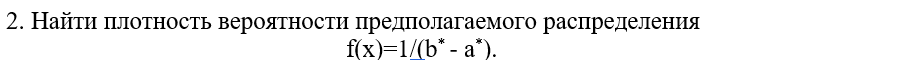
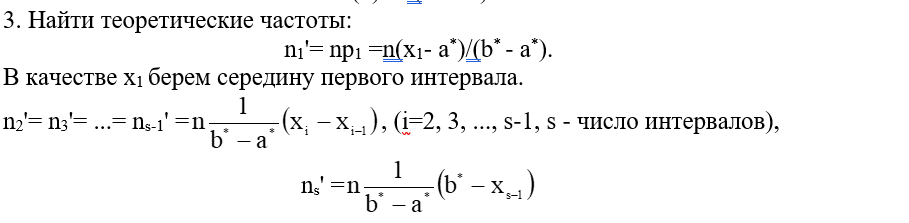

In [24]:
n_i = np.zeros(s)

for x in randArr:
    for i in range(s):
        if edges[i] <= x < edges[i+1]:
            n_i[i] += 1
            break
    else:
        if x == edges[-1]:
            n_i[-1] += 1

ni_prime = np.zeros(s)

for i in range(s):
    x_i = (edges[i] + edges[i+1]) / 2        
    if a_star <= x_i <= b_star:
        ni_prime[i] = N * h / (b_star - a_star)
    else:
        ni_prime[i] = 0
    
print(ni_prime)

[12.7790997 12.7790997 12.7790997 12.7790997 12.7790997 12.7790997
 12.7790997 12.7790997]
